In [1]:
!git clone https://github.com/PavanMohanN/bliq.git

fatal: destination path 'bliq' already exists and is not an empty directory.


In [2]:
cd bliq

/content/bliq


In [3]:
pip install -e .

Obtaining file:///content/bliq
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for bliq (pyproject.toml) ... done
  Created wheel for bliq: filename=bliq-1.0.0-0.editable-py3-none-any.whl size=4832 sha256=11d3cbd5b27cf9a3aaf489bd59aff3c0f2343bec8c0aa719b6ab90850ae1cb6d
  Stored in directory: /tmp/pip-ephem-wheel-cache-2k6iz48p/wheels/65/b3/16/45edabe3331ae08d223ed871a93cc3ccde817abeef4d5e5aa3
Successfully built bliq
  Attempting uninstall: bliq
    Found existing installation: bliq 1.0.0
    Uninstalling bliq-1.0.0:
      Successfully uninstalled bliq-1.0.0


In [4]:
import torch
from bliq.model import BLiqNet
print("Success!")

Success!


Stress-testing BLiqNet on Figure-8 Lemniscate...
[Epoch 0] Loss: 8248.1367 | F: 18.9816 Inv: 2671.2932 Lat: 1066.5536
[Epoch 100] Loss: 60.1164 | F: 0.5695 Inv: 1.4745 Lat: 262.9460
[Epoch 200] Loss: 26.9683 | F: 1.7570 Inv: 0.9468 Lat: 110.1927
[Epoch 300] Loss: 13.5542 | F: 0.2581 Inv: 0.3318 Lat: 60.6405
[Epoch 400] Loss: 10.3245 | F: 0.6669 Inv: 0.7266 Lat: 36.2881
[Epoch 500] Loss: 29.0957 | F: 0.2380 Inv: 7.6722 Lat: 27.3073
[Epoch 600] Loss: 4.8990 | F: 0.2382 Inv: 0.1801 Lat: 19.8390
[Epoch 700] Loss: 4.3694 | F: 0.3225 Inv: 0.1615 Lat: 16.8360
[Epoch 800] Loss: 5.4157 | F: 0.2082 Inv: 0.8113 Lat: 13.1313
[Epoch 900] Loss: 3.1785 | F: 0.1626 Inv: 0.2287 Lat: 10.9726
[Epoch 1000] Loss: 2.0981 | F: 0.1075 Inv: 0.0475 Lat: 8.6196
[Epoch 1100] Loss: 1.7417 | F: 0.0958 Inv: 0.0517 Lat: 6.8515
[Epoch 1200] Loss: 1.4930 | F: 0.0897 Inv: 0.0578 Lat: 5.5653
[Epoch 1300] Loss: 1.5024 | F: 0.1230 Inv: 0.0816 Lat: 5.0465
[Epoch 1400] Loss: 1.4916 | F: 0.1191 Inv: 0.1135 Lat: 4.4272
[Epoch 

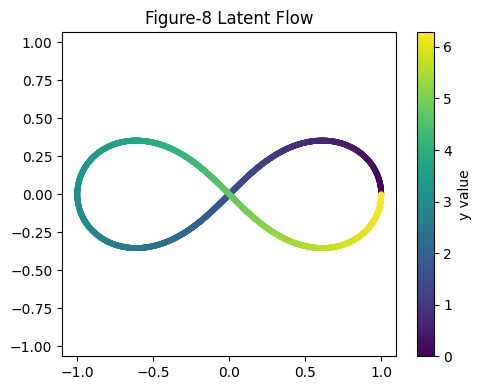

In [7]:
import torch
import numpy as np
from bliq.model import BLiqNet
from bliq.utils import compute_metrics, plot_manifold

def generate_lemniscate_data(n=3000):
    # Target: 1D Phase [0, 2pi]
    t = torch.linspace(0, 2 * np.pi, n).view(-1, 1)

    # Input: 2D Figure-8 Coordinates
    # x = cos(t) / (1 + sin^2(t))
    # y = sin(t)cos(t) / (1 + sin^2(t))
    denom = 1 + torch.sin(t)**2
    x1 = torch.cos(t) / denom
    x2 = (torch.sin(t) * torch.cos(t)) / denom

    x = torch.cat([x1, x2], dim=1)
    return x, t

# 1. Setup Data
x, t_true = generate_lemniscate_data()

# 2. Initialize (Higher capacity for the 'crossing' logic)
model = BLiqNet(input_dim=2, output_dim=1, hidden_dim=256, t_span=(0.0, 4.0))

# 3. Train (More epochs needed to resolve the intersection)
print("Stress-testing BLiqNet on Figure-8 Lemniscate...")
model.fit(x, t_true, epochs=2000, lambda_inv=3.0, lambda_rec=0.01)

# 4. Evaluation
with torch.no_grad():
    t_pred = model.forward(x)
    # Check if we can sample the intersection points
    x_rec = model.inverse(t_true, noise_level=0.2)

r2, rmse = compute_metrics(t_true, t_pred)
print(f"\nStress Test Results:")
print(f"Forward R2: {r2:.4f}")
print(f"Forward RMSE: {rmse:.4f}")

# Visualize the 'Spine' - See if it breaks at the center
plot_manifold(x, t_true, title="Figure-8 Latent Flow")